# Variability Analysis Notebook

This notebook performs the following steps:

1. **Plot Gene Expression Distribution**
2. **Compute Variability**
3. **Visualize Variability Across Datasets**

## Xenium Data (Spatial Transcriptomics)

- Raw gene counts → `scanpy.pp.normalize_total(target_sum=1e4)` → `log1p` → compute variability (CV)

## Codex Data (Spatial Proteomics)

- Z-scored protein expression → compute variability (MSE, Kurtosis, Skewness, Gini)


## 1. Import Libraries and Functions

Load required packages and helper functions for data loading, variability computation, and plotting.

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')
import matplotlib.pyplot as plt

from tic.data import load_xenium_dataset, list_regions, load_region
from tic.metrics import compute_variability
from tic.plotting import plot_variability, plot_gene_distributions_by_category
from tic.constant import EPITHELIAL_GENES, MESENCHYMAL_GENES, EMT_TF
from utils.dataset.codex_upmc import UPMC_EPITHELIAL_GENES, UPMC_MESENCHYMAL_GENES

# For nicer plots
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## 2. Load Xenium Datasets and Compute Variability (CV)

We load three Xenium datasets (Breast, Kidney, Pancreas). Each is normalized with Scanpy (`target_sum=1e4`), log-transformed, and then we compute the Coefficient of Variation (CV) per gene.

In [2]:
# Xenium Breast
xenium_ffpe_human_breast = load_xenium_dataset(
    name='xenium_ffpe_human_breast',
    normalize='scanpy',
    log=True,
)
xenium_ffpe_human_breast = xenium_ffpe_human_breast[xenium_ffpe_human_breast.obs['cell_type'].str.lower().str.contains('tumor'), :]
print(f"Number of tumor cells: {xenium_ffpe_human_breast.obs['cell_type'].str.lower().str.contains('tumor').sum()}")
xenium_ffpe_human_breast_variability = compute_variability(
    xenium_ffpe_human_breast,
    dataset_type='xenium',
    metrics=['cv','entropy','nonzero_ratio']
)
print("Breast CV (top 5):")
print(xenium_ffpe_human_breast_variability.head(), "\n")
# Xenium Kidney
xenium_kidney_cancer = load_xenium_dataset(
    name='xenium_kidney_cancer',
    normalize='scanpy',
    log=True,
)
xenium_kidney_cancer = xenium_kidney_cancer[xenium_kidney_cancer.obs['cell_type'].str.lower().str.contains('tumor'), :]
print(f"Number of tumor cells: {xenium_kidney_cancer.obs['cell_type'].str.lower().str.contains('tumor').sum()}")
xenium_kidney_cancer_variability = compute_variability(
    xenium_kidney_cancer,
    dataset_type='xenium',
    metrics=['cv','entropy','nonzero_ratio']
)
print("Kidney CV (all genes):")
print(xenium_kidney_cancer_variability, "\n")
# Xenium Pancreas
xenium_pancreas_cancer = load_xenium_dataset(
    name='xenium_pancreas_cancer',
    normalize='scanpy',
    log=True,
)
xenium_pancreas_cancer = xenium_pancreas_cancer[xenium_pancreas_cancer.obs['cell_type'].str.lower().str.contains('tumor'), :]
print(f"Number of tumor cells: {xenium_pancreas_cancer.obs['cell_type'].str.lower().str.contains('tumor').sum()}")
xenium_pancreas_cancer_variability = compute_variability(
    xenium_pancreas_cancer,
    dataset_type='xenium',
    metrics=['cv','entropy','nonzero_ratio']
)
print("Pancreas CV (all genes):")
print(xenium_pancreas_cancer_variability)


Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast
2025-06-10 11:40:11,160 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast
2025-06-10 11:40:11,997 INFO Loaded LLM‐annotated cell types from /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/xenium_ffpe_human_breast_llm_cell_types.parquet
2025-06-10 11:40:11,997 | INFO     | tic.data.xenium.loader | Loaded LLM‐annotated cell types from /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/xenium_ffpe_human_breast_llm_cell_types.parquet
2025-06-10 11:40:12,112 INFO Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-10 11:40:12,112 | INFO     | tic.data.xenium.loader | Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-10 11:40:12,603 INFO Applied log1p transformation.
2025-06-10 11:40:12,603 | INFO     | tic.data.xenium.loader | Applied

Number of tumor cells: 225559


Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-06-10 11:40:13,745 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-06-10 11:40:13,858 INFO Loaded LLM‐annotated cell types from /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer/xenium_kidney_cancer_llm_cell_types.parquet
2025-06-10 11:40:13,858 | INFO     | tic.data.xenium.loader | Loaded LLM‐annotated cell types from /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer/xenium_kidney_cancer_llm_cell_types.parquet
2025-06-10 11:40:13,876 INFO Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-10 11:40:13,876 | INFO     | tic.data.xenium.loader | Normalized using `sc.pp.normalize_total(target_sum=1e4)`.


Breast CV (top 5):
              cv    entropy  nonzero_ratio
ABCC11  1.796896  15.713822       0.240212
ACTA2   1.640225  15.909513       0.274735
ACTG2   2.129769  15.323759       0.182790
ADAM9   1.883048  15.608794       0.222731
ADGRE5  7.993959  11.768909       0.015557 



2025-06-10 11:40:13,953 INFO Applied log1p transformation.
2025-06-10 11:40:13,953 | INFO     | tic.data.xenium.loader | Applied log1p transformation.
2025-06-10 11:40:13,953 INFO Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
2025-06-10 11:40:13,953 | INFO     | tic.data.xenium.loader | Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-10 11:40:13,982 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer


Number of tumor cells: 4051
Kidney CV (all genes):
                   cv    entropy  nonzero_ratio
ABCC11      13.739556   4.436936       0.005431
ACE2         7.095547   6.320369       0.019995
ACKR1        5.999559   6.790810       0.027647
ACTA2        2.823184   8.838319       0.114540
ACTG2        1.227702  10.668160       0.404591
...               ...        ...            ...
BLANK_0482  36.845390   1.580482       0.000741
BLANK_0489  45.227119   0.992547       0.000494
BLANK_0491  45.142937   0.995226       0.000494
BLANK_0494  63.639904   0.000000       0.000247
BLANK_0497  63.639622   0.000000       0.000247

[449 rows x 3 columns] 



2025-06-10 11:40:14,581 INFO Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-10 11:40:14,581 | INFO     | tic.data.xenium.loader | Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-10 11:40:14,861 INFO Applied log1p transformation.
2025-06-10 11:40:14,861 | INFO     | tic.data.xenium.loader | Applied log1p transformation.
2025-06-10 11:40:14,864 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-10 11:40:14,864 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


Number of tumor cells: 37439
Pancreas CV (all genes):
                                 cv    entropy  nonzero_ratio
ABCC11                    34.969009   4.944315       0.000828
ACE2                       8.084092   9.147567       0.015225
ACKR1                     16.114679   7.172987       0.003873
ACTA2                      3.778879  11.268738       0.066348
ACTG2                      2.399669  12.444736       0.149870
...                             ...        ...            ...
NegControlCodeword_0538   96.991425   1.996229       0.000107
NegControlCodeword_0540  193.487198   0.000000       0.000027
BLANK_0006                58.845554   3.446176       0.000294
BLANK_0037                46.011242   4.156470       0.000481
BLANK_0069                73.193077   2.805972       0.000187

[531 rows x 3 columns]


## 3. Define Gene Categories (Epithelial, Mesenchymal, TF)

Combine Xenium and UPMC lists to define global sets for Epithelial (E), Mesenchymal (M), and EMT Transcription Factors (TF).

In [3]:
E_GENES = set(EPITHELIAL_GENES) | set(UPMC_EPITHELIAL_GENES)
M_GENES = set(MESENCHYMAL_GENES) | set(UPMC_MESENCHYMAL_GENES)

print("Epithelial genes:", E_GENES)
print("Mesenchymal genes:", M_GENES)
print("EMT Transcription Factors:", EMT_TF)


Epithelial genes: {'EPCAM', 'CDH1', 'PanCK', 'DSP'}
Mesenchymal genes: {'FN1', 'Vimentin', 'CollagenIV', 'VIM', 'ACTA2', 'CDH2', 'aSMA'}
EMT Transcription Factors: {'SNAI1', 'ZEB2', 'SNAI2', 'TWIST1', 'ZEB1'}


## 4. Plot Variability Across Xenium Datasets

We plot gene rank vs. CV for Breast, Kidney, and Pancreas datasets. Markers indicate the positions of E, M, and TF genes.

### 4.1 Plot CV

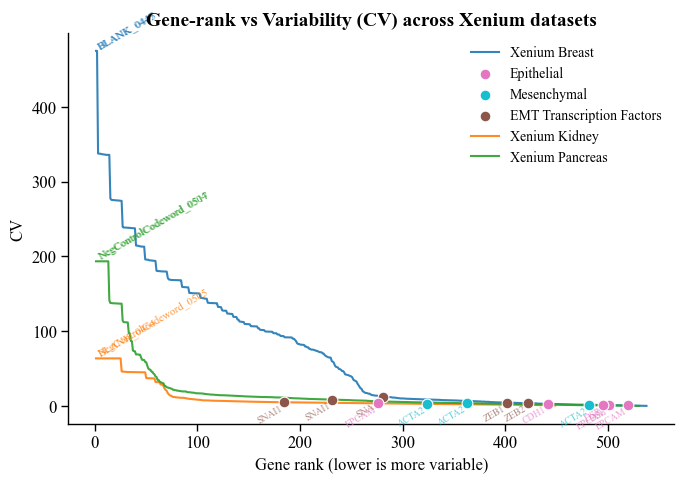

In [4]:
plot_variability(
    variability={
        "Xenium Breast": xenium_ffpe_human_breast_variability,
        "Xenium Kidney": xenium_kidney_cancer_variability,
        "Xenium Pancreas": xenium_pancreas_cancer_variability,
    },
    metric='cv',
    gene_categories={ 'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF },
    title="Gene-rank vs Variability (CV) across Xenium datasets",
    ascending=False,
    top_n=2,
    annotate_top=True,
    annotate_emt=True
)
plt.show()

### 4.2 Plot Entropy

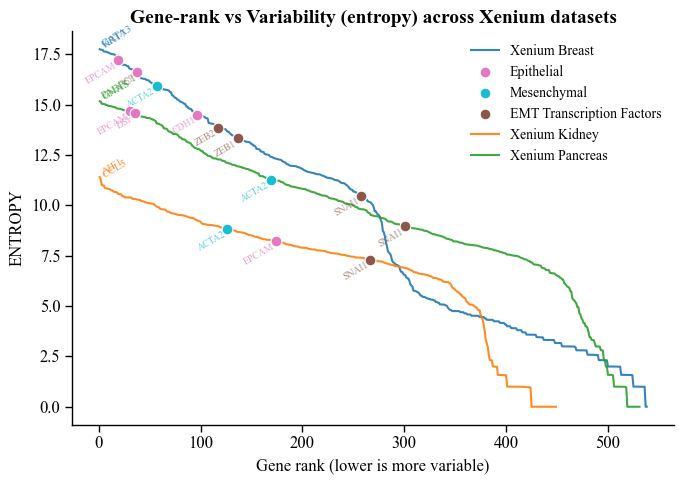

In [5]:
plot_variability(
    variability={
        "Xenium Breast": xenium_ffpe_human_breast_variability,
        "Xenium Kidney": xenium_kidney_cancer_variability,
        "Xenium Pancreas": xenium_pancreas_cancer_variability,
    },
    metric='entropy',
    gene_categories={ 'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF },
    title="Gene-rank vs Variability (entropy) across Xenium datasets",
    ascending=False,
    top_n=2,
    annotate_top=True,
    annotate_emt=True
)
plt.show()

### 4.3 Plot Non-Zero Ratio


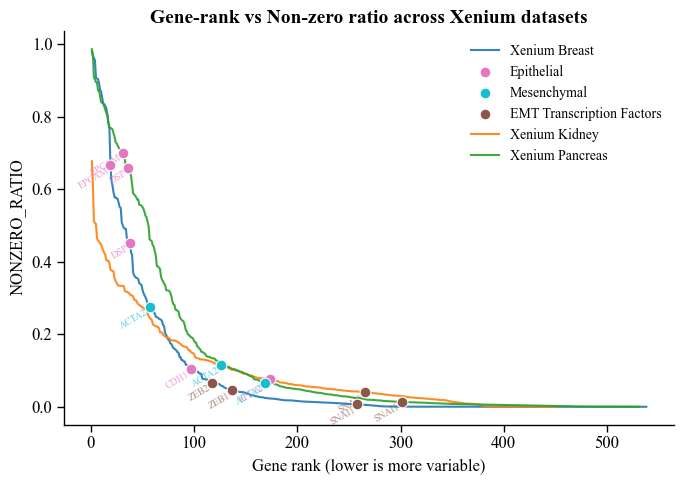

In [6]:
plot_variability(
    variability={
        "Xenium Breast": xenium_ffpe_human_breast_variability,
        "Xenium Kidney": xenium_kidney_cancer_variability,
        "Xenium Pancreas": xenium_pancreas_cancer_variability,
    },
    metric='nonzero_ratio',
    gene_categories={ 'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF },
    title="Gene-rank vs Non-zero ratio across Xenium datasets",
    ascending=False,
    top_n=0,
    annotate_top=True,
    annotate_emt=True
)
plt.show()

In [7]:
# Export a single csv file for each dataset: sort the genes by nonzero_ratio(only E genes + M genes + EMT TFs)

# Xenium Breast
xenium_ffpe_human_breast_variability.sort_values(by='nonzero_ratio', ascending=False).to_csv('../../tutorial/example_out/variablity/xenium_ffpe_human_breast_variability.csv')
# print the top 50 genes
print(f"Top 50 genes in Xenium Breast(sorted by nonzero_ratio): {xenium_ffpe_human_breast_variability.sort_values(by='nonzero_ratio', ascending=False).head(50).index.tolist()}")

# Xenium Kidney
xenium_kidney_cancer_variability.sort_values(by='nonzero_ratio', ascending=False).to_csv('../../tutorial/example_out/variablity/xenium_kidney_cancer_variability.csv')
print(f"Top 50 genes in Xenium Kidney(sorted by nonzero_ratio): {xenium_kidney_cancer_variability.sort_values(by='nonzero_ratio', ascending=False).head(50).index.tolist()}")

# Xenium Pancreas
xenium_pancreas_cancer_variability.sort_values(by='nonzero_ratio', ascending=False).to_csv('../../tutorial/example_out/variablity/xenium_pancreas_cancer_variability.csv')
print(f"Top 50 genes in Xenium Pancreas(sorted by nonzero_ratio): {xenium_pancreas_cancer_variability.sort_values(by='nonzero_ratio', ascending=False).head(50).index.tolist()}")

Top 50 genes in Xenium Breast(sorted by nonzero_ratio): ['GATA3', 'KRT7', 'TPD52', 'TACSTD2', 'CCND1', 'FOXA1', 'KRT23', 'SERPINA3', 'FLNB', 'ENAH', 'TOMM7', 'KRT8', 'SCD', 'ESR1', 'ANKRD30A', 'ERBB2', 'MLPH', 'FASN', 'EPCAM', 'NARS', 'CD9', 'MDM2', 'TFAP2A', 'SMS', 'CCDC6', 'AR', 'NOSTRIN', 'CTTN', 'TRAPPC3', 'SDC4', 'JUP', 'HMGA1', 'LARS', 'QARS', 'USP53', 'CCPG1', 'TRAF4', 'DSP', 'TMEM147', 'FAM107B', 'VOPP1', 'SMAP2', 'SH3YL1', 'SERHL2', 'TUBA4A', 'SRPK1', 'SEC11C', 'S100A14', 'ZNF562', 'PDE4A']
Top 50 genes in Xenium Kidney(sorted by nonzero_ratio): ['AIF1', 'CCL5', 'CD68', 'FCGR3A', 'PTPRC', 'MS4A6A', 'CFB', 'FGL2', 'MDM2', 'SEMA3C', 'MET', 'GZMK', 'GLIPR1', 'CXCR4', 'ACTG2', 'TFPI', 'VCAN', 'TRAC', 'C15orf48', 'FHL2', 'CD14', 'FCGR1A', 'BASP1', 'CD3E', 'CAV1', 'CD8A', 'TNC', 'CAVIN1', 'DST', 'PCNA', 'HAVCR2', 'STC1', 'SERPINB9', 'FAS', 'MALL', 'CXCL2', 'CD2', 'VSIG4', 'ANPEP', 'AQP9', 'MPEG1', 'CXCL9', 'PRDM1', 'C1orf162', 'KCNMA1', 'PMP22', 'GZMA', 'NKG7', 'MS4A4A', 'IL2RA']
To

In [8]:
# Export a single csv file for each dataset: sort the genes by nonzero_ratio(only E genes + M genes + EMT TFs), only keep the genes whose nonzero_ratio is greater than 0.8
import pandas as pd

xenium_ffpe_human_breast_variability = pd.read_csv('../../tutorial/example_out/variablity/xenium_ffpe_human_breast_variability.csv', index_col=0)
xenium_kidney_cancer_variability = pd.read_csv('../../tutorial/example_out/variablity/xenium_kidney_cancer_variability.csv', index_col=0)
xenium_pancreas_cancer_variability = pd.read_csv('../../tutorial/example_out/variablity/xenium_pancreas_cancer_variability.csv', index_col=0)

# only keep the genes whose nonzero_ratio is greater than 0.8
xenium_ffpe_human_breast_variability_nonzero_ratio_gt_08 = xenium_ffpe_human_breast_variability[xenium_ffpe_human_breast_variability['nonzero_ratio'] > 0.8]
xenium_kidney_cancer_variability_nonzero_ratio_gt_08 = xenium_kidney_cancer_variability[xenium_kidney_cancer_variability['nonzero_ratio'] > 0.8]
xenium_pancreas_cancer_variability_nonzero_ratio_gt_08 = xenium_pancreas_cancer_variability[xenium_pancreas_cancer_variability['nonzero_ratio'] > 0.8]

# sort the genes by nonzero_ratio
xenium_ffpe_human_breast_variability_nonzero_ratio_gt_08 = xenium_ffpe_human_breast_variability_nonzero_ratio_gt_08.sort_values(by='nonzero_ratio', ascending=False)
xenium_kidney_cancer_variability_nonzero_ratio_gt_08 = xenium_kidney_cancer_variability_nonzero_ratio_gt_08.sort_values(by='nonzero_ratio', ascending=False)
xenium_pancreas_cancer_variability_nonzero_ratio_gt_08 = xenium_pancreas_cancer_variability_nonzero_ratio_gt_08.sort_values(by='nonzero_ratio', ascending=False)

# export the csv files
xenium_ffpe_human_breast_variability_nonzero_ratio_gt_08.to_csv('../../tutorial/example_out/variablity/xenium_ffpe_human_breast_variability_nonzero_ratio_gt_0.8.csv')
xenium_kidney_cancer_variability_nonzero_ratio_gt_08.to_csv('../../tutorial/example_out/variablity/xenium_kidney_cancer_variability_nonzero_ratio_gt_0.8.csv')
xenium_pancreas_cancer_variability_nonzero_ratio_gt_08.to_csv('../../tutorial/example_out/variablity/xenium_pancreas_cancer_variability_nonzero_ratio_gt_0.8.csv')

print(f"Genes in Xenium Breast(sorted by nonzero_ratio): {xenium_ffpe_human_breast_variability_nonzero_ratio_gt_08.index.tolist()}")
print(f"Genes in Xenium Kidney(sorted by nonzero_ratio): {xenium_kidney_cancer_variability_nonzero_ratio_gt_08.index.tolist()}")
print(f"Genes in Xenium Pancreas(sorted by nonzero_ratio): {xenium_pancreas_cancer_variability_nonzero_ratio_gt_08.index.tolist()}")

Genes in Xenium Breast(sorted by nonzero_ratio): ['GATA3', 'KRT7', 'TPD52', 'TACSTD2', 'CCND1', 'FOXA1', 'KRT23', 'SERPINA3', 'FLNB', 'ENAH', 'TOMM7', 'KRT8', 'SCD', 'ESR1', 'ANKRD30A', 'ERBB2']
Genes in Xenium Kidney(sorted by nonzero_ratio): []
Genes in Xenium Pancreas(sorted by nonzero_ratio): ['PABPC1', 'GNAS', 'CFB', 'TMBIM6', 'EEF1B2', 'BTF3', 'SERPING1', 'NOP53', 'CFTR', 'SUMO2', 'SLC25A3', 'MYH9', 'DUSP1', 'FSTL3', 'PPA1', 'RHOA']


#### plot a bar chart for the EMT genes

Here we only include the Tumor Cells.The global rank of the metric(non-zero ratio of the gene across all cells) is colored in red.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Literal


def plot_gene_variability_bar(
    variability_df: pd.DataFrame,
    genes: List[str],
    metric: Literal["cv", "entropy", "nonzero_ratio"] = "cv",
    figsize: tuple = (8, 5),
    title: str = "Gene Variability Bar Plot",
    save_path: str = None
) -> None:
    """
    Plot a bar chart for selected genes with their variability metric values and ranks.

    Parameters
    ----------
    variability_df : pd.DataFrame
        DataFrame with index = gene names, columns = metrics ['cv', 'entropy', 'nonzero_ratio'].
    genes : List[str]
        List of genes to visualize (must exist in index).
    metric : {"cv", "entropy", "nonzero_ratio"}, default="cv"
        Metric to plot.
    figsize : tuple, default=(8, 5)
        Figure size.
    title : str, optional
        Title of the plot.
    save_path : str, optional
        If provided, save the figure to this path.
    """
    # Filter and sort
    available_genes = variability_df.index.intersection(genes)
    df = variability_df.loc[available_genes].copy()
    df = df.sort_values(by=metric, ascending=False)

    # Compute global rank
    full_sorted = variability_df[metric].sort_values(ascending=False)
    df["rank"] = df.index.map(lambda g: full_sorted.index.get_loc(g) + 1)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(df.index, df[metric], color="skyblue")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df.index, rotation=45, ha="right")

    # Annotate rank below bars
    for bar, rank in zip(bars, df["rank"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            0,
            f"#{rank}",
            ha="center",
            va="top",
            fontsize=9,
            rotation=45,
            color="red",
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

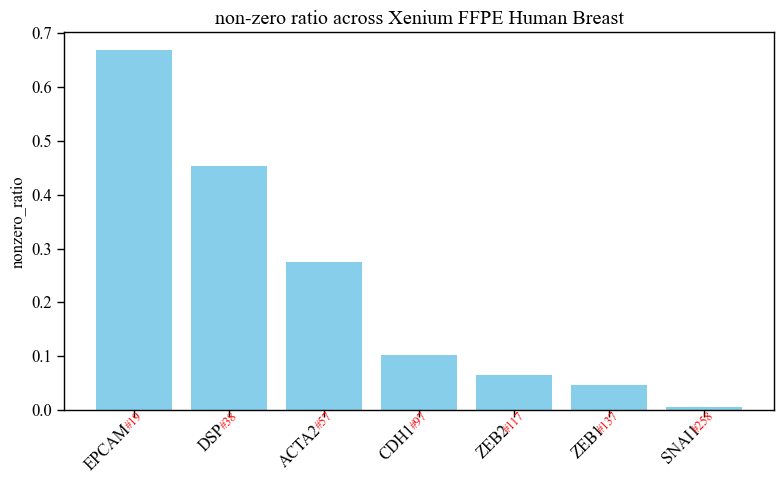

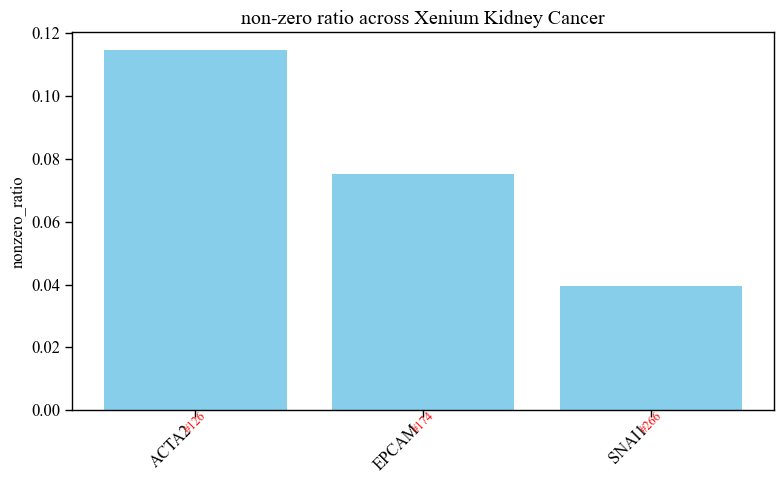

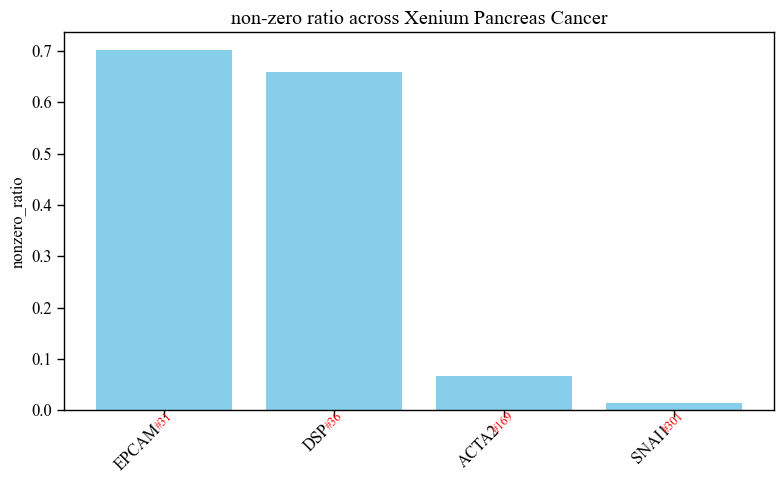

In [10]:
plot_gene_variability_bar(
    variability_df=xenium_ffpe_human_breast_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    metric='nonzero_ratio',
    title='non-zero ratio across Xenium FFPE Human Breast',
    save_path='../../tutorial/example_out/variablity/images/xenium_ffpe_human_breast_variability.png'
)

plot_gene_variability_bar(
    variability_df=xenium_kidney_cancer_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    metric='nonzero_ratio',
    title='non-zero ratio across Xenium Kidney Cancer',
    save_path='../../tutorial/example_out/variablity/images/xenium_kidney_cancer_variability.png'
)

plot_gene_variability_bar(
    variability_df=xenium_pancreas_cancer_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    metric='nonzero_ratio',
    title='non-zero ratio across Xenium Pancreas Cancer',
    save_path='../../tutorial/example_out/variablity/images/xenium_pancreas_cancer_variability.png'
)

## 5. Load Codex Regions and Compute Variability (MSE, Kurtosis, Skewness, Gini)

List available regions for UPMC, Charville, and DFCI. Then pick the first region from each, load it (preprocessed), and compute all four metrics.

In [11]:
# List Codex regions
upmc_regions = list_regions(dataset='upmc')
charville_regions = list_regions(dataset='charville')
dfci_regions = list_regions(dataset='dfci')

print(f"Number of regions in UPMC: {len(upmc_regions)}")
print(f"Number of regions in Charville: {len(charville_regions)}")
print(f"Number of regions in DFCI: {len(dfci_regions)}")

codex_upmc_region_1 = upmc_regions[0]
codex_charville_region_1 = charville_regions[0]
codex_dfci_region_1 = dfci_regions[0]

print(f"Codex UPMC Region 1: {codex_upmc_region_1}")
print(f"Codex Charville Region 1: {codex_charville_region_1}")
print(f"Codex DFCI Region 1: {codex_dfci_region_1}")


2025-06-10 11:40:15,830 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-10 11:40:15,830 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-10 11:40:19,701 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-10 11:40:19,701 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-10 11:40:19,701 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-10 11:40:19,910 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-10 11:40:19,912 INFO Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-10 11:40:19,912 | INFO     | tic.data.io | Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_charville/charville_raw_data.zip


2025-06-10 11:40:21,614 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-10 11:40:21,614 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-10 11:40:21,615 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-10 11:40:21,758 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-10 11:40:21,759 INFO Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-10 11:40:21,759 | INFO     | tic.data.io | Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_dfci/dfci_raw_data.zip


2025-06-10 11:40:22,122 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-10 11:40:22,122 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-10 11:40:22,122 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-10 11:40:22,151 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data


Number of regions in UPMC: 308
Number of regions in Charville: 292
Number of regions in DFCI: 58
Codex UPMC Region 1: UPMC_c001_v001_r001_reg001
Codex Charville Region 1: Charville_c001_v001_r001_reg001
Codex DFCI Region 1: s271_c001_v001_r001_reg001


In [12]:
# Load and compute variability for UPMC Region 1
upmc_region_1 = load_region(
    dataset='upmc',
    region_id=codex_upmc_region_1,
    preprocessed=True
)
upmc_region_1 = upmc_region_1[upmc_region_1.obs['cell_type'].str.lower().str.contains('tumor'), :]
upmc_region_1_variability = compute_variability(
    upmc_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini', 'entropy', 'pseudo_nonzero_ratios']
)
print("UPMC Region 1 variability (top 5):")
print(upmc_region_1_variability.head(), "\n")

# Load and compute variability for DFCI Region 1
dfci_region_1 = load_region(
    dataset='dfci',
    region_id=codex_dfci_region_1,
    preprocessed=True
)
dfci_region_1 = dfci_region_1[dfci_region_1.obs['cell_type'].str.lower().str.contains('tumor'), :]
dfci_region_1_variability = compute_variability(
    dfci_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini', 'entropy', 'pseudo_nonzero_ratios']
)
print("DFCI Region 1 variability (all):")
print(dfci_region_1_variability, "\n")

# Load and compute variability for Charville Region 1
charville_region_1 = load_region(
    dataset='charville',
    region_id=codex_charville_region_1,
    preprocessed=True
)
charville_region_1 = charville_region_1[charville_region_1.obs['cell_type'].str.lower().str.contains('tumor'), :]
charville_region_1_variability = compute_variability(
    charville_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini', 'entropy','pseudo_nonzero_ratios']
)
print("Charville Region 1 variability (top 5):")
print(charville_region_1_variability.head())


2025-06-10 11:40:22,157 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-10 11:40:22,157 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-10 11:40:25,491 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-10 11:40:25,491 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-10 11:40:25,492 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-10 11:40:25,706 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-10 11:40:25,724 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-06-10 11:40:25,726 | INFO     | tic.data.codex.loader | Loaded upmc (UPMC_c001_v001_r001_reg001): 43

UPMC Region 1 variability (top 5):
            mse   kurtosis  skewness      gini    entropy  \
CD11b  0.142205  52.180672  4.919263  0.203404   6.444067   
CD14   0.303941  17.819389  3.641684  0.336732   6.545970   
CD15   0.261610  23.056347  4.428059  0.423806   7.052797   
CD163  1.204667  -0.664033  0.023545  0.327076  10.275003   
CD20   1.326424   6.056212  2.034453  0.380606   9.301425   

       pseudo_nonzero>τ=0.0  pseudo_nonzero>τ=0.5  pseudo_nonzero>τ=1.0  
CD11b              0.068550              0.025475              0.010653  
CD14               0.068087              0.023622              0.006948  
CD15               0.100973              0.047244              0.034738  
CD163              0.712830              0.534044              0.323761  
CD20               0.466883              0.276517              0.166744   

Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_dfci/dfci_raw_data.zip


2025-06-10 11:40:26,078 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-10 11:40:26,078 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-10 11:40:26,079 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-10 11:40:26,101 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-10 11:40:26,114 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded dfci (s271_c001_v001_r001_reg001): 1967 cells * 41 biomarkers.
2025-06-10 11:40:26,115 | INFO     | tic.data.codex.loader | Loaded dfci (s271_c001_v001_r001_reg001): 19

DFCI Region 1 variability (all):
                    mse   kurtosis  skewness      gini   entropy  \
CD103          0.591196   3.327848  0.714875  0.176458  6.382479   
CD117          0.924553  -0.098589 -0.234239  0.172076  4.434771   
CD11b          1.140127   5.009802  1.962670  0.567258  1.971243   
CD11c          0.899354  -0.149841 -0.147916  0.223054  6.464556   
CD14           1.276994   2.065044  0.718003  0.178758  6.986962   
CD15           0.176880  15.953697  3.092410  0.403011  5.034184   
CD163          0.664965  -0.230320  0.106913  0.243379  4.724515   
CD183          1.319623   1.333480  0.049883  0.161200  7.126808   
CD197          0.357369  -0.230198  0.142410  0.214413  3.906679   
CD20           1.168402   5.121776  1.938976  0.347430  6.571054   
CD25           0.733005   1.565817  0.862906  0.206234  6.684133   
CD31           0.985425  -0.244019 -0.029350  0.223291  7.497526   
CD38           1.012997   6.244526  2.020496  0.418730  3.069227   
CD39           

2025-06-10 11:40:27,698 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-10 11:40:27,698 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-10 11:40:27,699 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-10 11:40:27,802 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-10 11:40:27,818 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded charville (Charville_c001_v001_r001_reg001): 2612 cells * 40 biomarkers.
2025-06-10 11:40:27,819 | INFO     | tic.data.codex.loader | Load

Charville Region 1 variability (top 5):
             mse   kurtosis  skewness      gini   entropy  \
CD107a  1.080045   0.182760  0.334854  0.274085  9.642686   
CD117   0.234152   5.764305 -0.792736  0.101652  9.405406   
CD11b   0.119135  19.140806  2.842777  0.198308  6.098895   
CD11c   0.452223   2.126292 -0.431698  0.118219  9.195390   
CD134   0.199409   0.899451  0.309319  0.151144  8.522755   

        pseudo_nonzero>τ=0.0  pseudo_nonzero>τ=0.5  pseudo_nonzero>τ=1.0  
CD107a              0.686587              0.482072              0.284197  
CD117               0.598274              0.139442              0.015272  
CD11b               0.092961              0.012616              0.005312  
CD11c               0.530544              0.232404              0.067729  
CD134               0.349270              0.079681              0.011288  


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from typing import List


def plot_gene_pseudo_nonzero_bars(
    variability_df: pd.DataFrame,
    genes: List[str],
    thresholds: List[float] = [0.0, 0.5, 1.0],
    figsize: tuple = (12, 4),
    title_prefix: str = "Pseudo Non-Zero Ratio",
    save_path: str = None,
) -> None:
    """
    Plot side-by-side bar charts for selected genes under multiple pseudo-nonzero thresholds.

    Parameters
    ----------
    variability_df : pd.DataFrame
        DataFrame with columns like 'pseudo_nonzero>τ=0.0', 'pseudo_nonzero>τ=0.5', ...
    genes : List[str]
        List of genes to visualize (must exist in index).
    thresholds : List[float], default = [0.0, 0.5, 1.0]
        Thresholds to plot, matching column names in the format 'pseudo_nonzero>τ={threshold}'.
    figsize : tuple, default=(12, 4)
        Figure size.
    title_prefix : str, optional
        Title prefix (each subplot will be titled as f"{prefix} (τ={t})").
    save_path : str, optional
        If given, save the figure to this path.
    """
    cols = [f"pseudo_nonzero>τ={t}" for t in thresholds]
    missing = set(cols) - set(variability_df.columns)
    if missing:
        raise ValueError(f"Missing columns in variability_df: {missing}")

    available_genes = variability_df.index.intersection(genes)
    df = variability_df.loc[available_genes, cols].copy()

    # Compute global ranks
    ranks = {
        col: variability_df[col].rank(ascending=False).astype(int).loc[available_genes]
        for col in cols
    }

    # Plot
    fig, axes = plt.subplots(1, len(thresholds), figsize=figsize, sharey=True)
    if len(thresholds) == 1:
        axes = [axes]

    for ax, tau, col in zip(axes, thresholds, cols):
        sub_df = df[[col]].sort_values(by=col, ascending=False)
        sub_ranks = ranks[col].loc[sub_df.index]

        bars = ax.bar(sub_df.index, sub_df[col], color="skyblue")
        ax.set_title(f"{title_prefix} (τ={tau})")
        ax.set_ylabel("Pseudo Non-Zero Ratio")
        ax.set_xticks(range(len(sub_df)))
        ax.set_xticklabels(sub_df.index, rotation=45, ha="right")

        for bar, rank in zip(bars, sub_ranks):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                0,
                f"#{rank}",
                ha="center",
                va="top",
                fontsize=9,
                rotation=45,
                color="red",
            )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

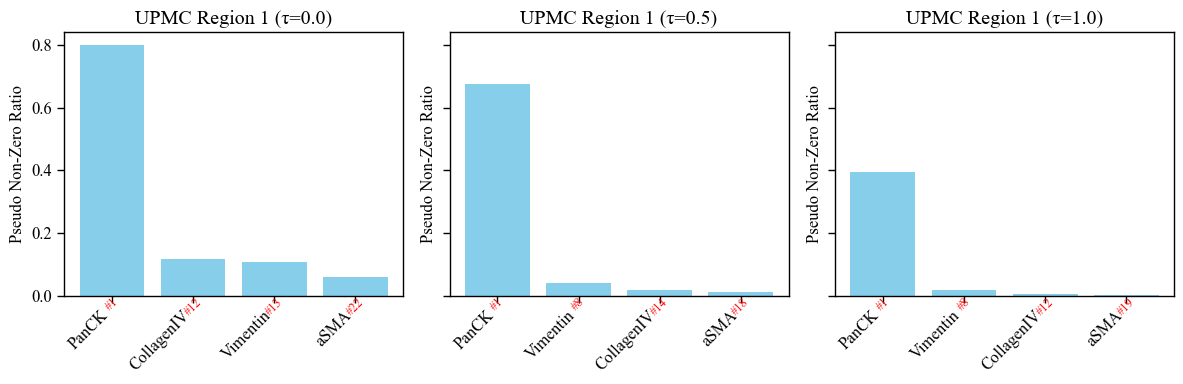

In [14]:
plot_gene_pseudo_nonzero_bars(
    variability_df=upmc_region_1_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    title_prefix='UPMC Region 1',
    save_path='../../tutorial/example_out/variablity/images/upmc_region_1_variability.png'
)

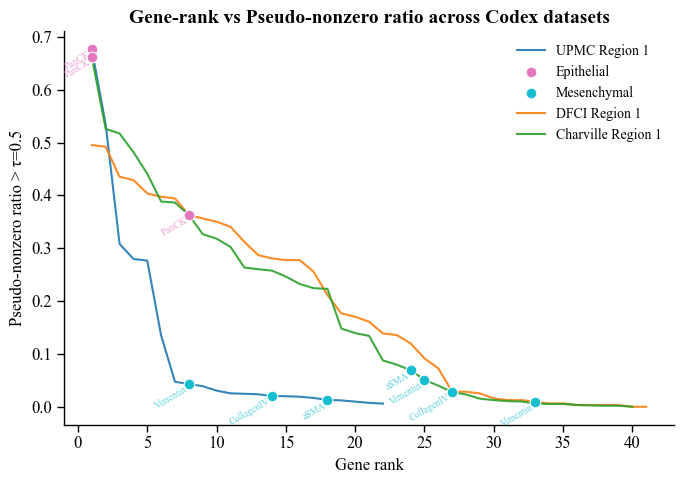

In [15]:
plot_variability(
    variability={
        "UPMC Region 1": upmc_region_1_variability,
        "DFCI Region 1": dfci_region_1_variability,
        "Charville Region 1": charville_region_1_variability,
    },
    metric='pseudo_nonzero>τ=0.5',
    gene_categories={ 'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF },
    title="Gene-rank vs Pseudo-nonzero ratio across Codex datasets",
    x_axis_label="Gene rank",
    y_axis_label="Pseudo-nonzero ratio > τ=0.5",
    ascending=False,
    top_n=0,
    annotate_top=True,
    annotate_emt=True
)
plt.show()

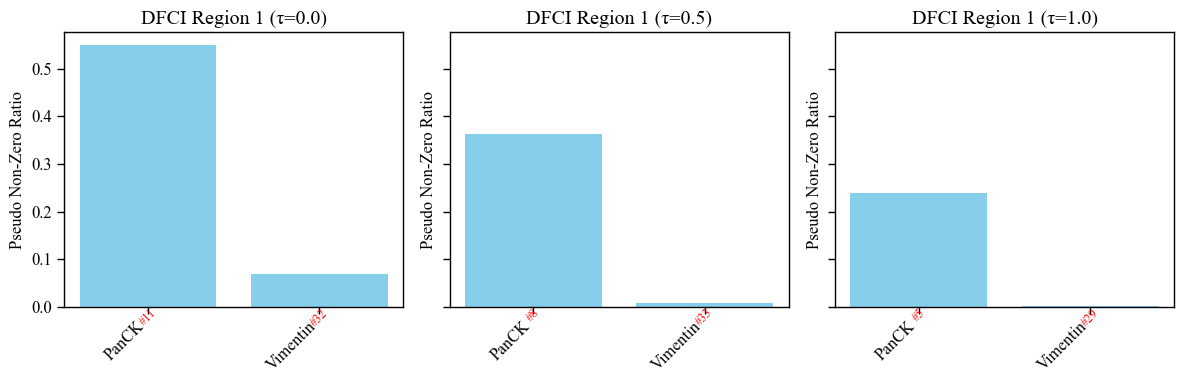

In [16]:
plot_gene_pseudo_nonzero_bars(
    variability_df=dfci_region_1_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    title_prefix='DFCI Region 1',
    save_path='../../tutorial/example_out/variablity/images/dfci_region_1_variability.png'
)

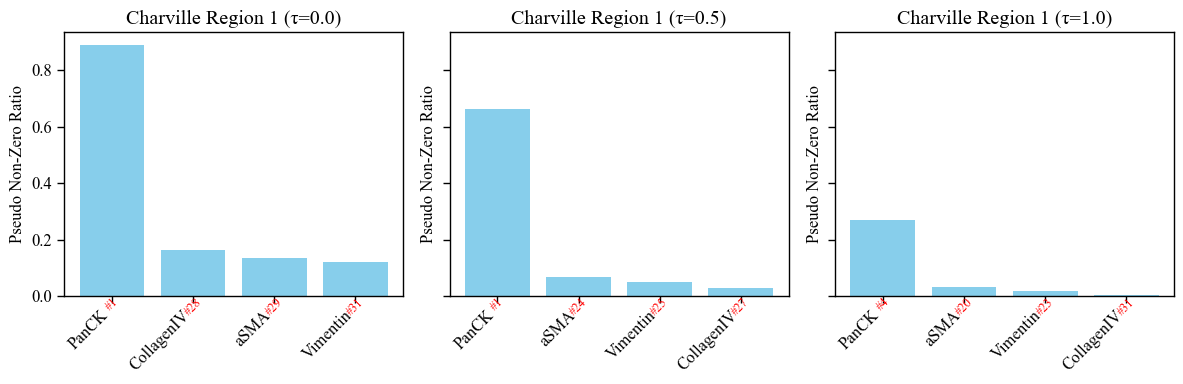

In [17]:
plot_gene_pseudo_nonzero_bars(
    variability_df=charville_region_1_variability,
    genes=list(E_GENES|M_GENES|EMT_TF),
    title_prefix='Charville Region 1',
    save_path='../../tutorial/example_out/variablity/images/charville_region_1_variability.png'
)

## 6. Load Xenium Pancreas (Z-scored) as Codex-like Input and Compute Variability

We also demonstrate computing Codex metrics on a Xenium dataset that was z-scored (so it simulates a preprocessed space akin to Codex).

In [18]:
xenium_pancreas_cancer_zscored = load_xenium_dataset(
    name='xenium_pancreas_cancer',
    normalize='zscore',
)
xenium_pancreas_cancer_zscored = xenium_pancreas_cancer_zscored[xenium_pancreas_cancer_zscored.obs['cell_type'].str.lower().str.contains('tumor'), :]
print(f"Number of tumor cells: {xenium_pancreas_cancer_zscored.obs['cell_type'].str.lower().str.contains('tumor').sum()}")
xenium_pancreas_cancer_zscored_variability = compute_variability(
    xenium_pancreas_cancer_zscored,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini']
)
print("Xenium Pancreas Z-scored variability (top 5):")
print(xenium_pancreas_cancer_zscored_variability.head())

Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-10 11:40:28,611 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-10 11:40:29,479 INFO Normalized using `zscore`.
2025-06-10 11:40:29,479 | INFO     | tic.data.xenium.loader | Normalized using `zscore`.
2025-06-10 11:40:29,479 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-10 11:40:29,479 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


Number of tumor cells: 37439
Xenium Pancreas Z-scored variability (top 5):
             mse     kurtosis   skewness      gini
ABCC11  0.799791  1203.461670  34.723103  0.999172
ACE2    0.240613    84.862206   8.756671  0.985411
ACKR1   0.150193   295.242737  16.723724  0.996204
ACTA2   0.146533    38.354134   5.141577  0.941031
ACTG2   1.173987    15.868843   3.338853  0.871445


## 7. Plot Variability (Kurtosis, Skewness) Across Codex & Z-scored Xenium

Compare Codex regions (UPMC, DFCI, Charville) and the Xenium pancreas z-scored dataset by plotting gene rank vs. Kurtosis and Skewness. Use log scale on the y-axis.

<Axes: title={'center': 'Gene-rank vs Skewness (Codex & Xenium Z-scored)'}, xlabel='Gene rank (lower is more variable)', ylabel='log(SKEWNESS)'>

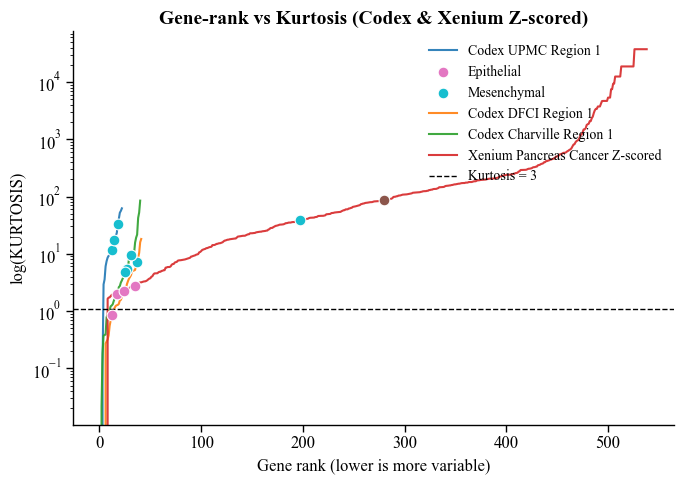

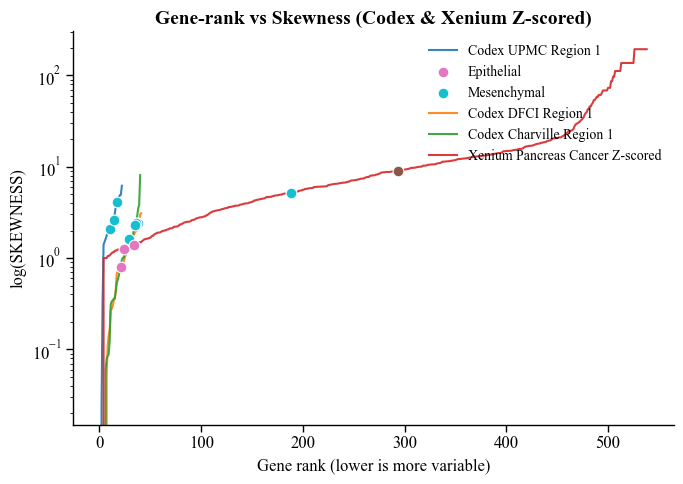

In [19]:
# Kurtosis plot
plot_variability(
    variability={
        "Codex UPMC Region 1": upmc_region_1_variability,
        "Codex DFCI Region 1": dfci_region_1_variability,
        "Codex Charville Region 1": charville_region_1_variability,
        "Xenium Pancreas Cancer Z-scored": xenium_pancreas_cancer_zscored_variability,
    },
    metric='kurtosis',
    log_y=True,
    ascending=True,
    gene_categories={'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF},
    title="Gene-rank vs Kurtosis (Codex & Xenium Z-scored)",
    top_n=2,
    annotate_top=False,
    annotate_emt=False,
)

# Skewness plot
plot_variability(
    variability={
        "Codex UPMC Region 1": upmc_region_1_variability,
        "Codex DFCI Region 1": dfci_region_1_variability,
        "Codex Charville Region 1": charville_region_1_variability,
        "Xenium Pancreas Cancer Z-scored": xenium_pancreas_cancer_zscored_variability,
    },
    metric='skewness',
    log_y=True,
    ascending=True,
    gene_categories={'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF},
    title="Gene-rank vs Skewness (Codex & Xenium Z-scored)",
    top_n=2,
    annotate_top=False,
    annotate_emt=False,
)


<Axes: title={'center': 'Gene-rank vs Entropy (Codex)'}, xlabel='Gene rank (lower is more variable)', ylabel='ENTROPY'>

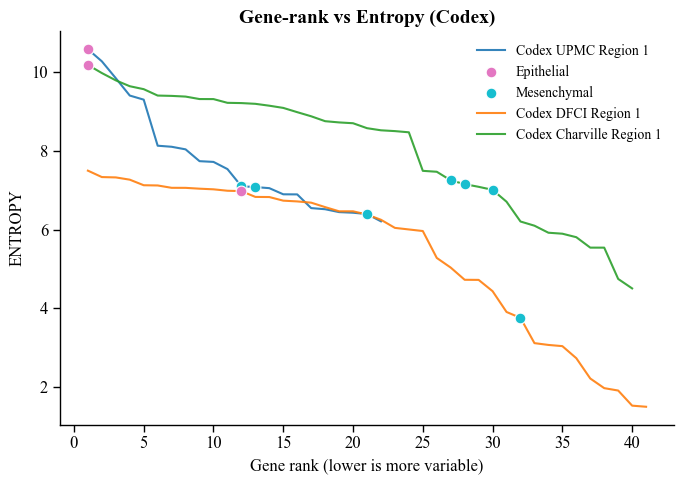

In [20]:
# Entropy plot
plot_variability(
    variability={
        "Codex UPMC Region 1": upmc_region_1_variability,
        "Codex DFCI Region 1": dfci_region_1_variability,
        "Codex Charville Region 1": charville_region_1_variability,
    },
    metric='entropy',
    ascending=False,
    gene_categories={'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF},
    title="Gene-rank vs Entropy (Codex)",
    top_n=2,
    annotate_top=False,
    annotate_emt=False,
)



## 8. Plot Gene Expression Distributions by Category

Finally, we show distribution plots of gene expression for selected categories (E, M, TF) in one Codex region and one Xenium z-scored dataset.

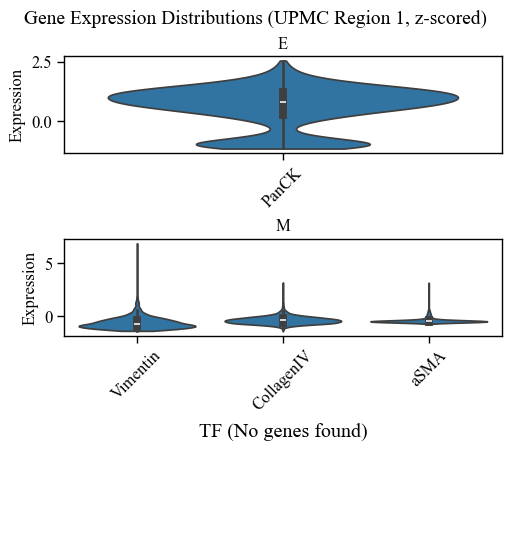

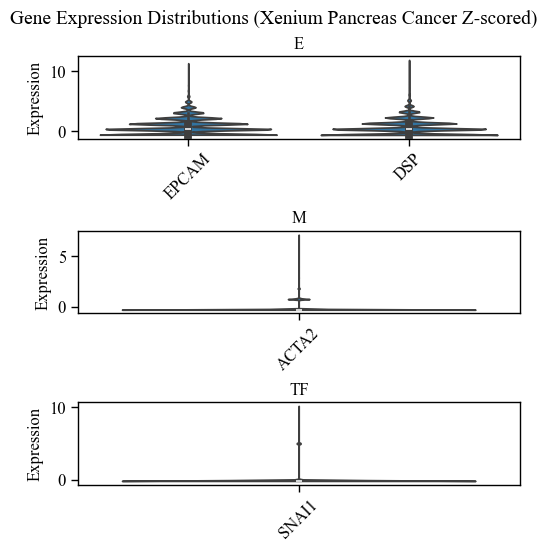

In [21]:
# UPMC Region 1 distributions (z-scored)
plot_gene_distributions_by_category(
    adata=upmc_region_1,
    gene_dict={'E': E_GENES, 'M': M_GENES, 'TF': EMT_TF},
    title="Gene Expression Distributions (UPMC Region 1, z-scored)"
)
plt.show()

# Xenium Pancreas Z-scored distributions
plot_gene_distributions_by_category(
    adata=xenium_pancreas_cancer_zscored,
    gene_dict={'E': E_GENES, 'M': M_GENES, 'TF': EMT_TF},
    title="Gene Expression Distributions (Xenium Pancreas Cancer Z-scored)"
)
plt.show()

Gene 'CDH1' not found in adata.var_names.
Gene 'PanCK' not found in adata.var_names.


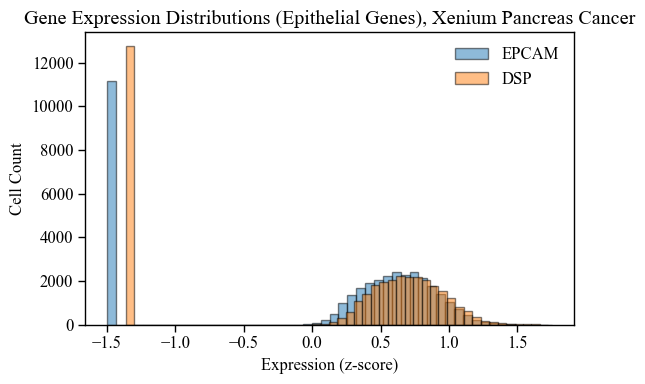

In [22]:
from tic.plotting.gen_distribution import plot_gene_histograms

plot_gene_histograms(
    adata=xenium_pancreas_cancer,
    genes=list(E_GENES),
    bins=50,
    subplot=False,
    zscore=True,
    figsize=(6, 4),
    expression_key="X",
    title="Gene Expression Distributions (Epithelial Genes), Xenium Pancreas Cancer"
)

Gene 'ZEB2' not found in adata.var_names.
Gene 'SNAI2' not found in adata.var_names.
Gene 'TWIST1' not found in adata.var_names.
Gene 'ZEB1' not found in adata.var_names.


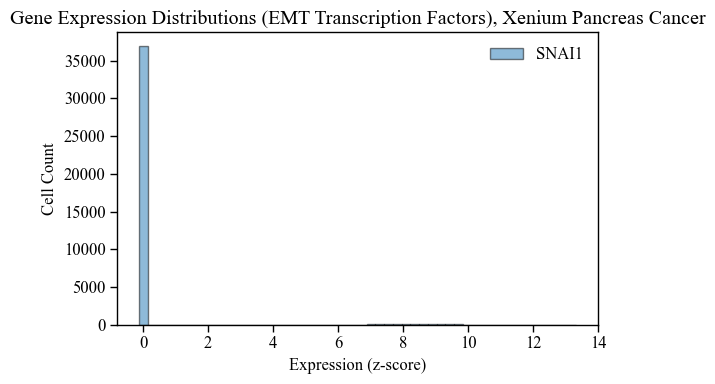

In [23]:
from tic.plotting.gen_distribution import plot_gene_histograms

plot_gene_histograms(
    adata=xenium_pancreas_cancer,
    genes=list(EMT_TF),
    bins=50,
    subplot=False,
    zscore=True,
    figsize=(6, 4),
    expression_key="X",
    title="Gene Expression Distributions (EMT Transcription Factors), Xenium Pancreas Cancer"
)

Gene 'FN1' not found in adata.var_names.
Gene 'Vimentin' not found in adata.var_names.
Gene 'CollagenIV' not found in adata.var_names.
Gene 'VIM' not found in adata.var_names.
Gene 'CDH2' not found in adata.var_names.
Gene 'aSMA' not found in adata.var_names.


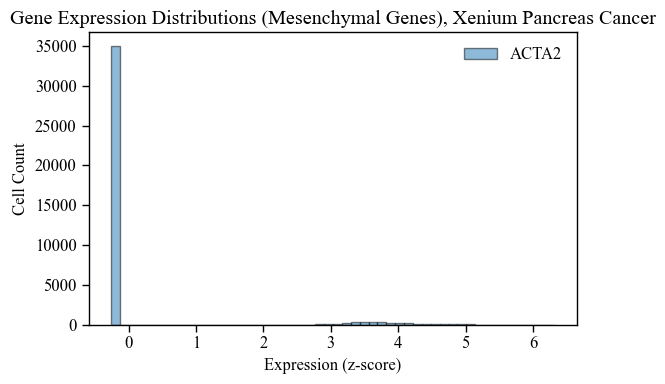

In [24]:
plot_gene_histograms(
    adata=xenium_pancreas_cancer,
    genes=list(M_GENES),
    bins=50,
    subplot=False,
    zscore=True,
    figsize=(6, 4),
    expression_key="X",
    title="Gene Expression Distributions (Mesenchymal Genes), Xenium Pancreas Cancer"
)

Gene 'EPCAM' not found in adata.var_names.
Gene 'CDH1' not found in adata.var_names.
Gene 'DSP' not found in adata.var_names.


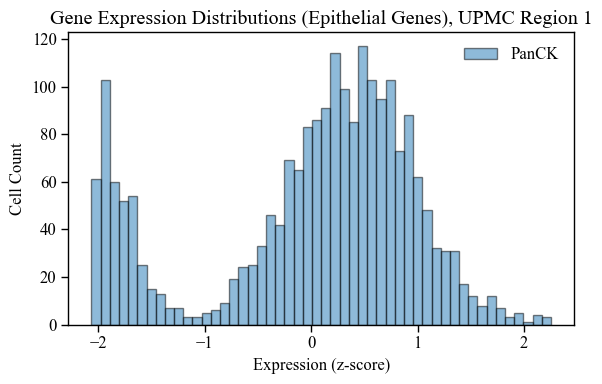

In [25]:
plot_gene_histograms(
    adata=upmc_region_1,
    genes=list(E_GENES),
    bins=50,
    subplot=False,
    zscore=True,
    figsize=(6, 4),
    expression_key="X",
    title="Gene Expression Distributions (Epithelial Genes), UPMC Region 1"
)

Gene 'FN1' not found in adata.var_names.
Gene 'VIM' not found in adata.var_names.
Gene 'ACTA2' not found in adata.var_names.
Gene 'CDH2' not found in adata.var_names.


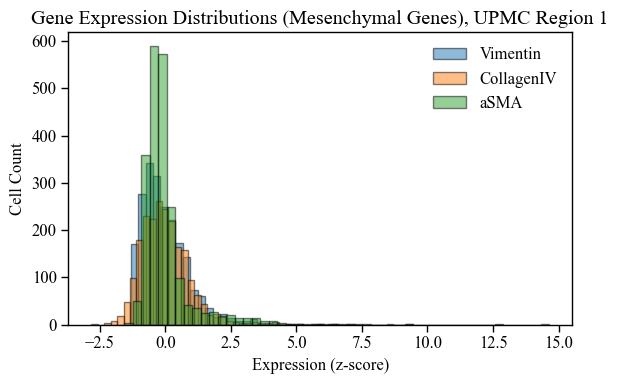

In [26]:
plot_gene_histograms(
    adata=upmc_region_1,
    genes=list(M_GENES),
    bins=50,
    subplot=False,
    zscore=True,
    figsize=(6, 4),
    expression_key="X",
    title="Gene Expression Distributions (Mesenchymal Genes), UPMC Region 1"
)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from anndata import AnnData
from scipy.sparse import issparse

def plot_gene_vs_total_count(
    adata: AnnData,
    gene: str,
    use_raw: bool = False,
    log_scale: bool = True,
    title: str = None,
    figsize: tuple = (6, 5),
    save_path: str = None
):
    """
    Scatter plot: X = specific gene expression, Y = total gene count per cell

    Parameters
    ----------
    adata : AnnData
        The annotated data matrix.
    gene : str
        Name of the gene to plot on the X-axis.
    use_raw : bool, default=False
        Whether to use adata.raw.X instead of adata.X.
    log_scale : bool, default=True
        Whether to log-transform the axes.
    title : str, optional
        Custom plot title.
    figsize : tuple
        Figure size.
    save_path : str, optional
        Path to save the plot. If None, shows the plot.
    """
    if use_raw:
        X = adata.raw.X
        var_names = adata.raw.var_names
    else:
        X = adata.X
        var_names = adata.var_names

    if gene not in var_names:
        raise ValueError(f"Gene '{gene}' not found in var_names.")

    # Extract gene expression and total count
    gene_idx = np.where(var_names == gene)[0][0]
    gene_expr = X[:, gene_idx].toarray().flatten() if issparse(X) else X[:, gene_idx]
    total_expr = X.sum(axis=1).A1 if issparse(X) else X.sum(axis=1)

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(gene_expr, total_expr, alpha=0.3, s=5)

    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(f"Log {gene} Expression")
        plt.ylabel("Log Total Expression Count")
    else:
        plt.xlabel(f"{gene} Expression")
        plt.ylabel("Total Expression Count")

    plt.title(title or f"{gene} Expression vs. Total Count")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

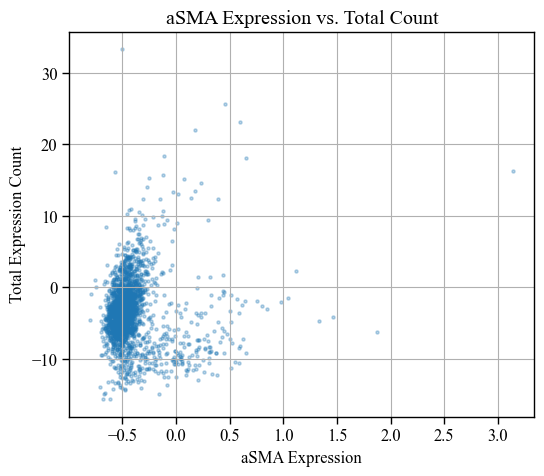

In [28]:
plot_gene_vs_total_count(
    adata=upmc_region_1,
    gene='aSMA',
    log_scale=False
)

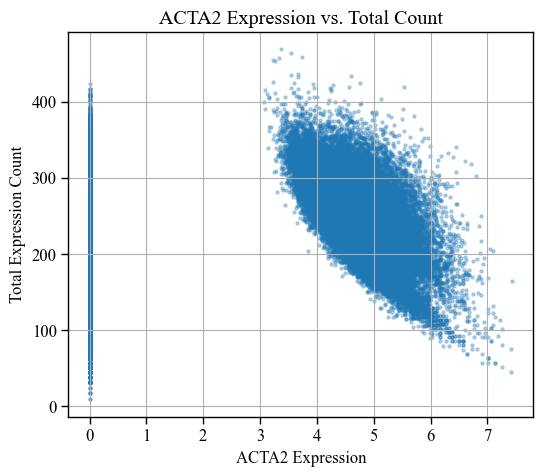

In [29]:
plot_gene_vs_total_count(
    adata=xenium_ffpe_human_breast,
    gene='ACTA2',
    log_scale=False
)

---
**End of Notebook**